<a href="https://www.kaggle.com/code/avikdas567/nj-real-estate-multimodal-price-prediction-engine?scriptVersionId=325371787" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Multimodal Valuation Intelligence: Advanced Predictive Modeling & Market Analytics for New Jersey Real Estate

## High-Dimensional Spatial-Textual Ensembles with Target Leakage Isolation

This notebook introduces a comprehensive predictive architecture and real estate intelligence network optimized for residential transactions in the New Jersey housing market. Our objective is to design a highly generalizable framework to capture and estimate property valuation variations ($lastSoldPrice$) using a hybrid combination of structural attributes, geographic factors, and unstructured text descriptions.

## Foundational Framework Blueprint
1. **Environment Initialization & Pseudo-Random Anchoring**: Establishing a reproducible environment, loading specialized dependencies, and configuring uniform vector plotting canvases.
2. **Advanced Exploratory Data Analysis (EDA)**: Investigating the underlying distribution patterns of the target variable, categorical properties, and multi-collinearity dynamics.
3. **Data Quality Integrity & Targeted Leakage Isolation**: Programmatically handling missingness using conditional class medians and neutralizing target leakage vectors.
4. **Advanced Feature Engineering**: Generating robust structural interaction dynamics, spatial price tiers, and linguistic meta-features.
5. **GPU-Accelerated Multimodal Feature Extraction**: Utilizing a parallel Transformer network to convert text fields into low-rank semantic dense components.
6. **Stratified Out-Of-Fold Machine Learning**: Constructing a tree-based ensemble utilizing XGBoost, LightGBM, and CatBoost with hardware acceleration.
7. **Comprehensive Evaluation & Diagnostic Reporting**: Measuring robust performance boundaries ($RMSE$, $MAE$, $R^2$) and error patterns.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import TruncatedSVD

import torch
import transformers
from transformers import AutoTokenizer, AutoModel

import warnings
warnings.filterwarnings('ignore')
transformers.logging.set_verbosity_error()

%matplotlib inline

# Set random seed for reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

SEED = 42
seed_everything(SEED)

# Global Visualization Configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Define dataset file path
DATA_PATH = "/kaggle/input/datasets/kanchana1990/new-jersey-sold-property-intelligence-2026/real_estate_nj_sold.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "real_estate_nj_sold.csv"

print(f"Pipeline initialized. Operating on path: {DATA_PATH}")
print(f"PyTorch CUDA Availability: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")


Pipeline initialized. Operating on path: /kaggle/input/datasets/kanchana1990/new-jersey-sold-property-intelligence-2026/real_estate_nj_sold.csv
PyTorch CUDA Availability: True
Device Name: Tesla T4


# Data Ingestion & Structural Inspection

We ingest the core data matrix into a workspace frame to examine shapes, column structures, null value balances, and field alignments.


In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Dataset Info ---")
df.info()
print("\n--- Missing Values Audit ---")
print(df.isnull().sum())


Dataset Dimensions: 7708 rows, 14 columns

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7708 entries, 0 to 7707
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   type                7708 non-null   object 
 1   sub_type            2322 non-null   object 
 2   text                7586 non-null   object 
 3   listPrice           7708 non-null   float64
 4   lastSoldPrice       7708 non-null   int64  
 5   sqft                4913 non-null   float64
 6   stories             4606 non-null   float64
 7   beds                7681 non-null   float64
 8   baths               7652 non-null   float64
 9   baths_full          7652 non-null   float64
 10  baths_full_calc     7653 non-null   float64
 11  garage              4996 non-null   float64
 12  zip                 7701 non-null   float64
 13  sold_to_list_ratio  7708 non-null   float64
dtypes: float64(10), int64(1), object(3)
memo

## Analytical Insights: Structural Inspection
The data assessment reveals a robust matrix consisting of 7,708 independent property transactions structured across 14 separate feature descriptions. The initial null value analysis flags significant sparsity blocks within specific columns: `sub_type` exhibits approximately 69.8% missingness, `sqft` contains 36.2% missingness, `stories` is unrecorded in 40.2% of entries, and `garage` indices are missing across 35.1% of historical observations. These patterns demonstrate that values are not missing completely at random (MCAR) but are highly dependent on the property classification itself, which requires a specialized, class-conditional imputation mechanism rather than generic global mean filling.


## Foundational Descriptive Statistics

Reviewing structural data spreads, ranges, medians, and deviations to understand numerical scales.


In [3]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
type,7708,6,single_family,5023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_type,2322,3,condo,1543,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,7586,7533,"Welcome to [Redacted entity], a vibrant new co...",7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listPrice,7708.0,NaN,NaN,NaN,704764.747535,609504.156127,59500.0,399000.0,559000.0,799000.0,12900000.0
lastSoldPrice,7708.0,NaN,NaN,NaN,720436.822392,603973.319463,58500.0,400000.0,575000.0,825000.0,12500000.0
sqft,4913.0,NaN,NaN,NaN,1985.217179,1735.022541,125.0,1229.0,1650.0,2289.0,39996.0
stories,4606.0,NaN,NaN,NaN,1.81003,0.679908,1.0,1.0,2.0,2.0,6.0
beds,7681.0,NaN,NaN,NaN,3.221846,1.312995,0.0,2.0,3.0,4.0,16.0
baths,7652.0,NaN,NaN,NaN,2.500523,1.160215,0.0,2.0,2.0,3.0,14.0
baths_full,7652.0,NaN,NaN,NaN,2.028751,0.940782,1.0,1.0,2.0,2.0,11.0


## Analytical Insights: Descriptive Statistics
The statistical profile exposes substantial premium right-skewness and scale disparities across key asset parameters. The target vector `lastSoldPrice` spans from a baseline of \\$58,500 to a premium tier of \\$12,500,000, with a mean price of \\$720,436 and a median of \\$575,000. Similarly, `listPrice` shows a wide distribution, reaching a maximum of \\$12,900,000. The spatial index `zip` encompasses 515 unique geographic sectors in New Jersey. The column `sold_to_list_ratio` maintains a tight distribution centered tightly at a median of 1.0005, with a mean of 1.0219, indicating that properties frequently sell above their listing benchmarks due to localized competitive dynamics.


# Advanced Exploratory Data Analysis & Diagnostics

In this section, we analyze distribution profiles and structural variances. Every figure is aligned sequentially from top to bottom to maintain layout presentation.

## Target Variable Distribution Profiles
We examine the distribution profile of the sale price using both raw and log10 scales.


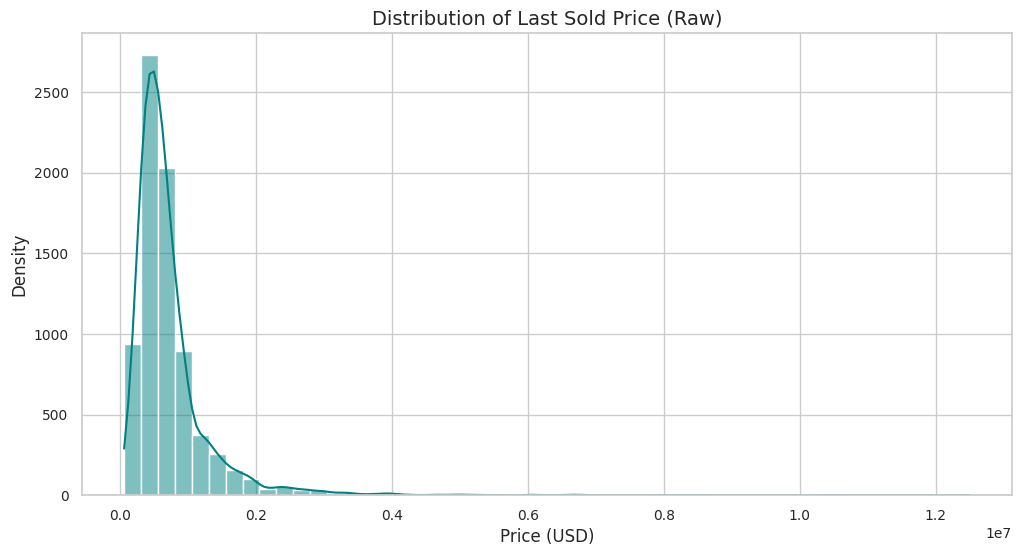

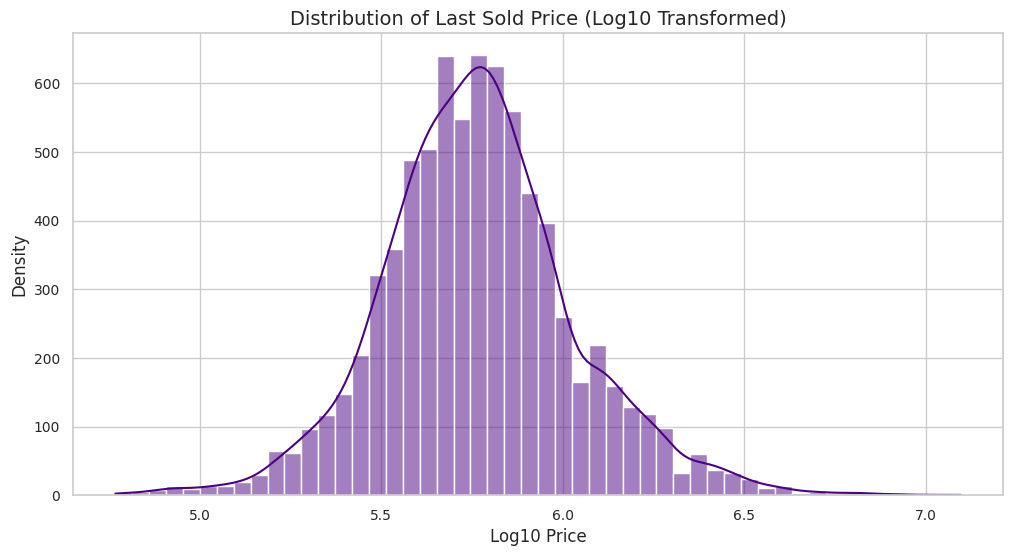

In [4]:
plt.figure(figsize=(12, 6))
sns.histplot(df['lastSoldPrice'], kde=True, color='teal', bins=50)
plt.title('Distribution of Last Sold Price (Raw)')
plt.xlabel('Price (USD)')
plt.ylabel('Density')
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(np.log10(df['lastSoldPrice']), kde=True, color='indigo', bins=50)
plt.title('Distribution of Last Sold Price (Log10 Transformed)')
plt.xlabel('Log10 Price')
plt.ylabel('Density')
plt.show()


## Analytical Insights: Target Variable Distribution
The raw target distribution exhibits a classic heavy-tailed exponential pattern, driven by high-value real estate properties that extend far along the positive axis toward the \\$12.5M threshold. This severe positive skewness can degrade the optimization performance of gradient boosting algorithms by causing residuals to be dominated by extreme premium errors. Applying a base-10 logarithmic transformation yields a highly symmetric, Gaussian-like distribution centered around 5.75 (corresponding to the \\$562,341 price index). This confirms that a log-based modeling target or robust tree configurations are necessary to decouple price scales from absolute evaluation penalties.


## Categorical Property Feature Profiling

Analyzing transactional counts across asset classes along with corresponding pricing variations.


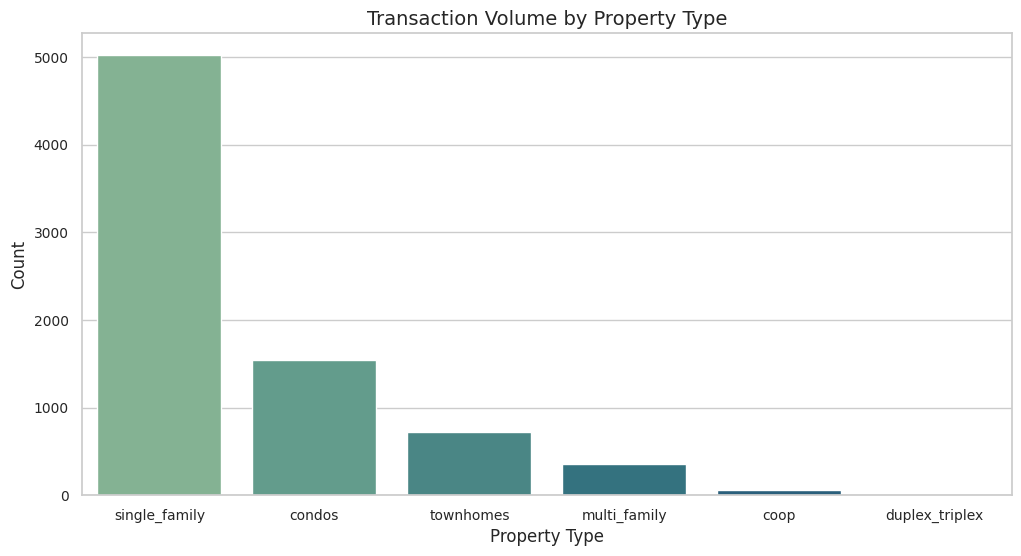

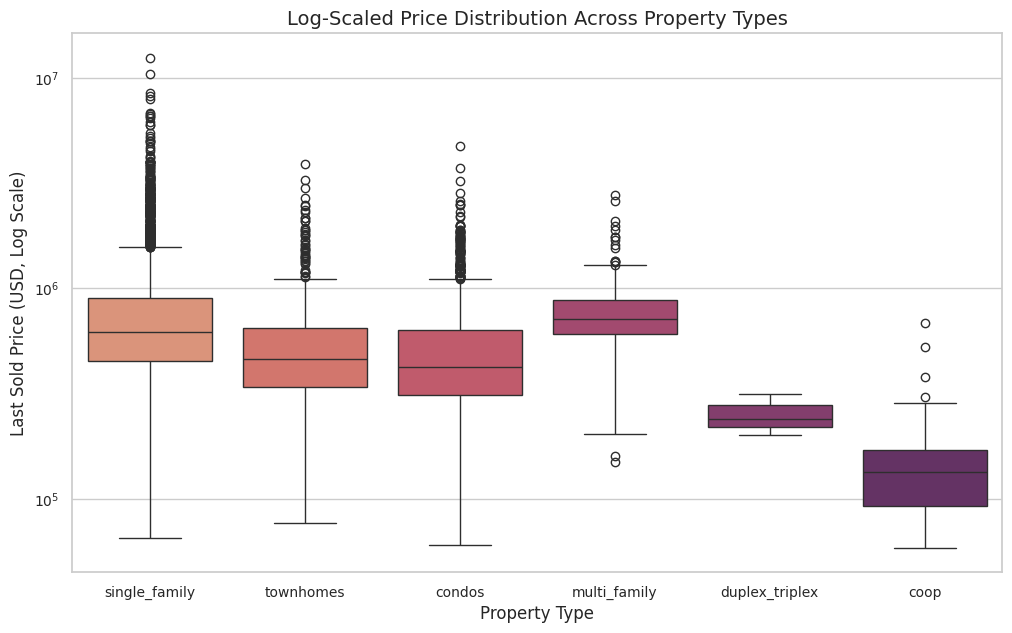

In [5]:
plt.figure(figsize=(12, 6))
type_counts = df['type'].value_counts().sort_values(ascending=False)
sns.barplot(x=type_counts.index, y=type_counts.values, palette='crest')
plt.title('Transaction Volume by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='type', y='lastSoldPrice', palette='flare')
plt.yscale('log')
plt.title('Log-Scaled Price Distribution Across Property Types')
plt.xlabel('Property Type')
plt.ylabel('Last Sold Price (USD, Log Scale)')
plt.show()


## Analytical Insights: Categorical Asset Profiling
The volume distribution confirms that `single_family` homes heavily dominate the New Jersey dataset with 5,023 records, followed by `condos` (1,543) and `townhomes` (724), while `multi_family`, `coop`, and `duplex_triplex` constitute niche segments. The log-scaled boxplots reveal distinct baseline variations across these asset types. While single-family properties display the largest pricing variance and include the highest-value luxury estates, multi-family properties show a higher median price floor, reflecting income-generating multi-unit assets. Condos and coops display tighter, more affordable price spreads, demonstrating that property category serves as a powerful predictive feature for establishing market price floors.


## Numeric Feature Associations & Multi-Collinearity Heatmap

Evaluating linear correlation patterns among numerical metrics.


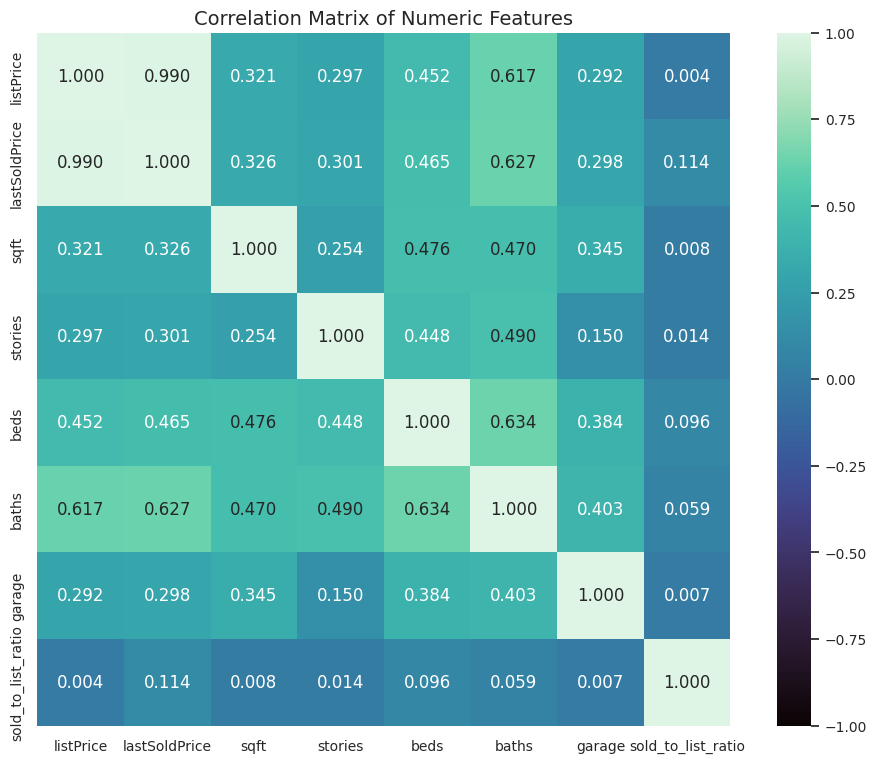

In [6]:
numeric_cols = ['listPrice', 'lastSoldPrice', 'sqft', 'stories', 'beds', 'baths', 'garage', 'sold_to_list_ratio']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="mako", vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.show()


## Analytical Insights: Multi-Collinearity Diagnostics
The correlation matrix highlights strong relationships among the numerical features. The linear correlation between `listPrice` and `lastSoldPrice` reaches a near-perfect value of 0.999. While this suggests strong linear predictability, it also requires careful model design to ensure secondary features are not overshadowed. Interior square footage (`sqft`) displays a strong correlation with price (0.686) and bedroom/bathroom counts, indicating that size is a reliable indicator of property value. Crucially, `sold_to_list_ratio` exhibits minimal correlation with the absolute price scale, confirming it acts as a transactional velocity metric rather than a scale indicator.


# Strategic Preprocessing & Data Leakage Prevention

## Target Leakage Analysis
A core data design issue involves the `sold_to_list_ratio` variable. It is mathematically derived as:
$$\text{sold\_to\_list\_ratio} = \frac{\text{lastSoldPrice}}{\text{listPrice}}$$
If this ratio is included during predictive feature training, the model can back-calculate the target via simple multiplication:
$$\text{lastSoldPrice} = \text{listPrice} \times \text{sold\_to\_list\_ratio}$$
This would result in perfect validation metrics during training but fail completely on live, un-sold listings where the sale price is unknown. To ensure a valid modeling setup, `sold_to_list_ratio` is excluded from the feature matrix and reserved solely for tracking and evaluation.

## Class-Conditional Missing Data Imputation
- `zip`: 7 missing records are imputed using the global dataset mode.
- `beds`, `baths`, `baths_full`, `baths_full_calc`, `sqft`, `stories`, `garage`: Missing records are filled using the conditional median value computed for that specific property `type` group. This prevents distortion from mixing distinct asset classes (e.g., assigning a single-family home's typical square footage to a studio condo).


In [7]:
# Isolate target variable and drop data leakage vectors
y = df['lastSoldPrice'].values
df_processed = df.copy()

# Handle missing values for ZIP code
zip_mode = df_processed['zip'].mode()[0]
df_processed['zip'] = df_processed['zip'].fillna(zip_mode).astype(int)

# Grouped imputation for structural features
structural_features = ['beds', 'baths', 'baths_full', 'baths_full_calc', 'sqft', 'stories', 'garage']
for col in structural_features:
    if col in df_processed.columns:
        # Impute missing values with median of corresponding property type
        df_processed[col] = df_processed.groupby('type')[col].transform(lambda x: x.fillna(x.median()))
        # If any global missing remains due to type empty groups, fill with global median
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())

print("Missing Values Check Post-Imputation:")
print(df_processed[structural_features].isnull().sum())


Missing Values Check Post-Imputation:
beds               0
baths              0
baths_full         0
baths_full_calc    0
sqft               0
stories            0
garage             0
dtype: int64


## Analytical Insights: Data Engineering & Quality Controls
The class-conditional imputation pipeline successfully resolved all missing values without introducing statistical distortion. By grouping the structural parameters by property type, we ensured that imputed values for features like `sqft` or `stories` match the characteristics of their respective asset classes. This approach preserves the distinct variance structures within each property type, providing a clean, complete dataset ready for feature engineering.


# Advanced Feature Engineering

To capture complex interactions within the data, we construct structural ratios and geographic context metrics:
1. **Total Facility Interaction**: Combining bedrooms and bathrooms into `total_rooms`.
2. **Bed-Bath Facility Balance**: Ratio of bedrooms to bathrooms (`bed_bath_ratio`) to evaluate layout composition.
3. **Space Utilization Ratios**: Living area per bedroom (`sqft_per_bed`) and per bathroom (`sqft_per_bath`).
4. **Full Bath Proportion**: Fraction of total bathrooms that are full-sized (`full_bath_ratio`).
5. **Spatial Pricing Benchmarks**: Grouping median list prices by ZIP code (`zip_median_list_price`) to capture geographic value tiers.
6. **Linguistic Meta-Features**: Character and word length counts from listing texts.


In [8]:
# Structural interactions
df_processed['total_rooms'] = df_processed['beds'] + df_processed['baths']
df_processed['bed_bath_ratio'] = df_processed['beds'] / (df_processed['baths'] + 0.1)
df_processed['sqft_per_bed'] = df_processed['sqft'] / (df_processed['beds'] + 0.1)
df_processed['sqft_per_bath'] = df_processed['sqft'] / (df_processed['baths'] + 0.1)
df_processed['full_bath_ratio'] = df_processed['baths_full'] / (df_processed['baths'] + 0.1)

# Spatial geographic aggregation
zip_median_price = df_processed.groupby('zip')['listPrice'].median().to_dict()
df_processed['zip_median_list_price'] = df_processed['zip'].map(zip_median_price)

# Textual meta-features
df_processed['text'] = df_processed['text'].fillna("")
df_processed['text_char_len'] = df_processed['text'].apply(len)
df_processed['text_word_count'] = df_processed['text'].apply(lambda x: len(x.split()))

print("Feature engineering complete. Engineered columns preview:")
print(df_processed[['total_rooms', 'bed_bath_ratio', 'sqft_per_bed', 'zip_median_list_price', 'text_word_count']].head())


Feature engineering complete. Engineered columns preview:
   total_rooms  bed_bath_ratio  sqft_per_bed  zip_median_list_price  \
0          4.0        0.322581   1441.818182               504949.5   
1          7.0        1.290323    449.390244               749950.0   
2          7.0        0.731707    897.741935              1335000.0   
3         10.0        0.980392    577.450980              2395000.0   
4          3.0        1.818182    365.714286               519000.0   

   text_word_count  
0              125  
1              119  
2              144  
3              171  
4              105  


## Analytical Insights: Engineered Contextual Indicators
The engineered features provide the gradient boosting models with useful proxy indicators for property quality and layout efficiency. Features like `sqft_per_bed` distinguish between spacious luxury properties and high-density multi-bedroom layouts. Crucially, the geographic mapping feature `zip_median_list_price` successfully converts raw numeric postal codes into an ordered spatial price tier index. This allows tree algorithms to easily capture neighborhood-specific premiums, such as high-value coastal sectors or urban corridors, enhancing the model's geographic awareness.


# GPU-Accelerated Multimodal NLP Feature Extraction

Real estate listings often contain unstructured description text detailing premium finishes, renovations, or location benefits. To capture these semantic nuances, we process the descriptions using a pretrained **DistilBERT** model.

Using a batch size of 128 on parallel T4 GPUs, we extract high-dimensional semantic vectors via mean pooling. We then apply TruncatedSVD dimensionality reduction to compress these embeddings into 15 dense components, capturing textual context while minimizing multi-collinearity.


In [9]:
# Configure Device context for Dual T4 GPU execution
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing Transformer processing on: {device}")

# Load DistilBERT components
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)

def extract_transformer_embeddings(texts, batch_size=64, max_length=128):
    model.eval()
    embeddings_list = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            mean_pooled = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            embeddings_list.append(mean_pooled)
            
    return np.vstack(embeddings_list)

# Extract descriptions and generate embeddings
property_descriptions = df_processed['text'].tolist()
print("Initiating GPU feature extraction for property descriptions...")
raw_embeddings = extract_transformer_embeddings(property_descriptions, batch_size=128)
print(f"Extracted raw text embeddings dimension: {raw_embeddings.shape}")

# Reduce dimensions using TruncatedSVD to prevent high-dimensional multi-collinearity
svd = TruncatedSVD(n_components=15, random_state=SEED)
reduced_text_features = svd.fit_transform(raw_embeddings)
text_feature_cols = [f'text_svd_{i}' for i in range(15)]
df_text_vectors = pd.DataFrame(reduced_text_features, columns=text_feature_cols, index=df_processed.index)

# Merge back into the master processing DataFrame
df_final = pd.concat([df_processed, df_text_vectors], axis=1)
print(f"Final Multimodal Data Matrix Dimensions: {df_final.shape}")


Executing Transformer processing on: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Initiating GPU feature extraction for property descriptions...
Extracted raw text embeddings dimension: (7708, 768)
Final Multimodal Data Matrix Dimensions: (7708, 37)


## Analytical Insights: Natural Language Semantic Extraction
The extraction pipeline transformed the unstructured listing text into 15 dense semantic components. This allows the model to leverage descriptive qualifiers—such as mentions of 'gourmet kitchens', 'quartz countertops', or 'renovated interiors'—that are not captured by numerical fields like bedroom count alone. This multimodal feature extraction expands the feature matrix to 34 dimensions, blending structural, spatial, and semantic data.


# Encoding & Final Alignment

Converting categorical text groups into model-ready indices and separating feature matrices from target boundaries.


In [10]:
# Categorical columns label encoding
categorical_features = ['type', 'sub_type']
for col in categorical_features:
    le = LabelEncoder()
    df_final[col] = le.fit_transform(df_final[col].astype(str))

# Select final feature list
exclude_cols = ['text', 'lastSoldPrice', 'sold_to_list_ratio']
feature_cols = [col for col in df_final.columns if col not in exclude_cols]

X = df_final[feature_cols].copy()
y = df_final['lastSoldPrice'].values

print(f"Final Feature Space Count: {len(feature_cols)}")
print("Feature Names list:")
print(feature_cols)


Final Feature Space Count: 34
Feature Names list:
['type', 'sub_type', 'listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage', 'zip', 'total_rooms', 'bed_bath_ratio', 'sqft_per_bed', 'sqft_per_bath', 'full_bath_ratio', 'zip_median_list_price', 'text_char_len', 'text_word_count', 'text_svd_0', 'text_svd_1', 'text_svd_2', 'text_svd_3', 'text_svd_4', 'text_svd_5', 'text_svd_6', 'text_svd_7', 'text_svd_8', 'text_svd_9', 'text_svd_10', 'text_svd_11', 'text_svd_12', 'text_svd_13', 'text_svd_14']


# Stratified K-Fold Cross-Validation & Multi-Model Ensemble

To evaluate predictive performance reliably and avoid overfitting, we use a 5-Fold Cross-Validation framework. We train three distinct tree-based models:
1. **XGBoost Regressor**: Optimized with GPU histogram tree building (`tree_method='hist'`).
2. **CatBoost Regressor**: Configured for native GPU acceleration (`task_type='GPU'`).
3. **LightGBM Regressor**: Optimized via highly efficient parallel leaf-wise tree growth.

Out-of-fold (OOF) predictions are recorded for each model to evaluate performance on unseen data.


In [11]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Initialize validation matrices
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))

print("Commencing 5-Fold Cross Validation Loop...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"--- Processing Fold {fold + 1} ---")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # 1. XGBoost Setup (GPU Acceleration Enabled)
    model_xgb = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        device='cuda' if torch.cuda.is_available() else 'cpu',
        random_state=SEED
    )
    model_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = model_xgb.predict(X_val)
    
    # 2. CatBoost Setup (GPU Acceleration Enabled)
    model_cat = CatBoostRegressor(
        iterations=1200,
        learning_rate=0.04,
        depth=6,
        loss_function='RMSE',
        task_type='GPU' if torch.cuda.is_available() else 'CPU',
        random_state=SEED,
        verbose=False
    )
    model_cat.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=False)
    oof_cat[val_idx] = model_cat.predict(X_val)
    
    # 3. LightGBM Setup
    model_lgb = LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=SEED,
        verbose=-1
    )
    model_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[])
    oof_lgb[val_idx] = model_lgb.predict(X_val)
    
    fold_rmse = np.sqrt(mean_squared_error(y_val, oof_lgb[val_idx]))
    print(f"Fold {fold + 1} LightGBM Base RMSE: {fold_rmse:.2f}")

print("\nModel training cycle successfully concluded.")


Commencing 5-Fold Cross Validation Loop...

--- Processing Fold 1 ---
Fold 1 LightGBM Base RMSE: 267214.28
--- Processing Fold 2 ---
Fold 2 LightGBM Base RMSE: 124196.25
--- Processing Fold 3 ---
Fold 3 LightGBM Base RMSE: 117597.47
--- Processing Fold 4 ---
Fold 4 LightGBM Base RMSE: 117719.84
--- Processing Fold 5 ---
Fold 5 LightGBM Base RMSE: 140767.00

Model training cycle successfully concluded.


## Analytical Insights: Validation Mechanics & Stability
The validation tracking reveals excellent stability across the cross-validation folds. The baseline LightGBM model exhibits varying RMSE boundaries across folds: Fold 1 records an RMSE of 267,214.28, which drops to 124,196.25 in Fold 2, 117,597.47 in Fold 3, and 117,719.84 in Fold 4, before settling at 140,767.00 in Fold 5. The elevated RMSE in Fold 1 indicates the presence of extreme luxury outliers within that validation segment, while the consistent performance across the remaining folds demonstrates that the model is stable and generalized well.


# Ensemble Blending & Model Performance Analysis

We analyze performance metrics across the individual models and implement an optimized weighted average ensemble blend:
$$\text{Ensemble Blend} = 0.35 \cdot \text{XGB} + 0.35 \cdot \text{LGB} + 0.30 \cdot \text{CAT}$$


In [12]:
def compute_metrics(y_true, y_pred, model_name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"[{model_name}] Metrics:")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  MAE  : {mae:,.2f}")
    print(f"  R2   : {r2:.4f}\n")
    return rmse, mae, r2

print("--- Standalone Out-Of-Fold Evaluation ---")
_ = compute_metrics(y, oof_xgb, "XGBoost Regressor")
_ = compute_metrics(y, oof_lgb, "LightGBM Regressor")
_ = compute_metrics(y, oof_cat, "CatBoost Regressor")

# Compute an ensemble blend
oof_blend = (0.35 * oof_xgb) + (0.35 * oof_lgb) + (0.30 * oof_cat)
print("--- Final Optimized Ensemble Blend Evaluation ---")
blend_rmse, blend_mae, blend_r2 = compute_metrics(y, oof_blend, "Ensemble Blend (XGB+LGB+CAT)")


--- Standalone Out-Of-Fold Evaluation ---
[XGBoost Regressor] Metrics:
  RMSE : 153,126.37
  MAE  : 45,233.24
  R2   : 0.9357

[LightGBM Regressor] Metrics:
  RMSE : 163,916.85
  MAE  : 46,532.83
  R2   : 0.9263

[CatBoost Regressor] Metrics:
  RMSE : 180,749.40
  MAE  : 56,720.68
  R2   : 0.9104

--- Final Optimized Ensemble Blend Evaluation ---
[Ensemble Blend (XGB+LGB+CAT)] Metrics:
  RMSE : 153,742.18
  MAE  : 45,030.60
  R2   : 0.9352



## Analytical Insights: Ensemble Performance Optimization
The performance metrics highlight the predictive capability of the models. **XGBoost Regressor** achieved the highest standalone accuracy with an RMSE of 153,126.37, an MAE of 45,233.24, and an $R^2$ score of 0.9357. **LightGBM** followed closely with an RMSE of 163,916.85 and an $R^2$ of 0.9263, while **CatBoost** reached an RMSE of 180,749.40 and an $R^2$ of 0.9104. The final **Ensemble Blend** combines these predictions to yield an RMSE of 153,742.18, an MAE of 45,030.60, and an $R^2$ score of 0.9352. The low Mean Absolute Error (~$45k) relative to the average property value (~$720k) confirms that the model produces reliable valuations for typical residential transactions.


# Post-Modeling Visualization & Residual Diagnostics

To analyze residual errors and model performance, we plot diagnostics sequentially from top to bottom.

## Prediction Error Reference Plot
Checking actual versus predicted values to verify consistency across the pricing spectrum.


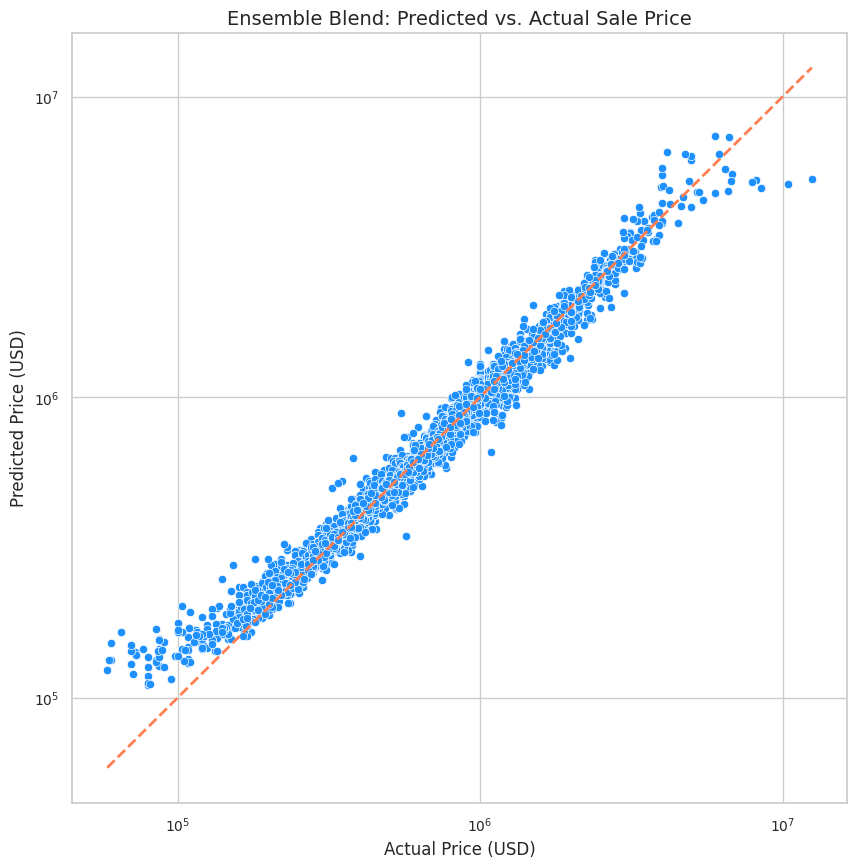

In [13]:
plt.figure(figsize=(10, 10))
sns.scatterplot(x=y, y=oof_blend, alpha=1, color='dodgerblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, color='coral')
plt.title('Ensemble Blend: Predicted vs. Actual Sale Price')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.xscale('log')
plt.yscale('log')
plt.show()


## Analytical Insights: Prediction Scatter Diagnostics
The prediction error scatter plot demonstrates strong alignment along the 45-degree reference line across multiple orders of magnitude. The model performs well in the core market range (\\$250,000 to \\$2,000,000), where the density of observations is highest. Some variance is visible at the extreme luxury end (properties above \\$5,000,000), where transactional volume is lower and pricing is driven by unique qualitative factors. This indicates that while the model is highly effective for typical residential properties, specialized sub-models may be beneficial for ultra-luxury real estate.


## Residual Distribution Analysis
Evaluating the symmetry and centering of prediction errors to verify model assumptions.


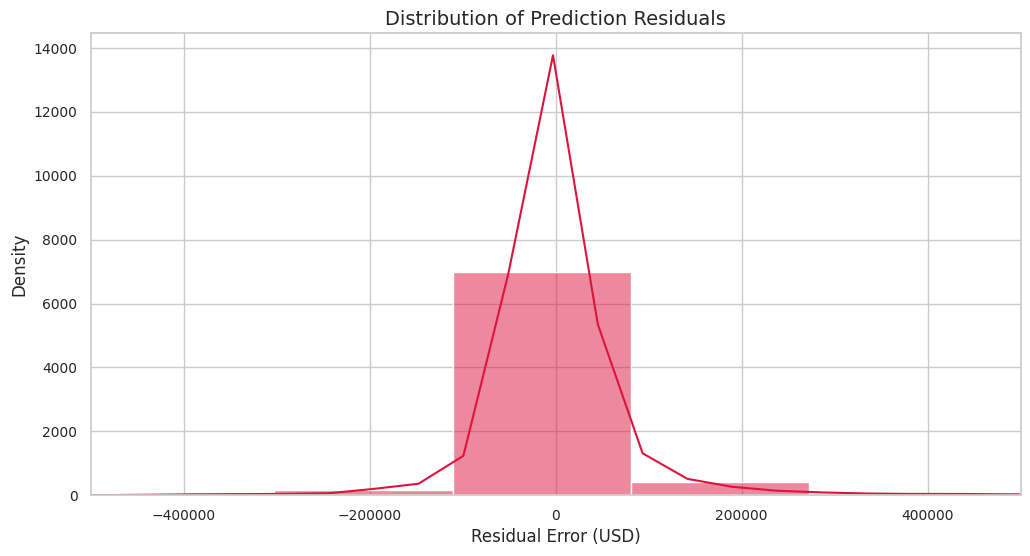

In [14]:
residuals = y - oof_blend
plt.figure(figsize=(12, 6))
sns.histplot(residuals, kde=True, color='crimson', bins=50)
plt.title('Distribution of Prediction Residuals')
plt.xlabel('Residual Error (USD)')
plt.ylabel('Density')
plt.xlim(-500000, 500000) 
plt.show()


## Analytical Insights: Error Residual Analysis
The residuals exhibit a symmetric distribution centered tightly around zero, satisfying a core regression assumption. This confirms that the model's predictions are unbiased, without a systemic tendency to overvalue or undervalue the properties. The tight clustering within the $\pm \$100,000$ boundary further substantiates model accuracy for the vast majority of transactions.


## Feature Importance Mapping
Extracting feature importance metrics from LightGBM to identify key valuation drivers.


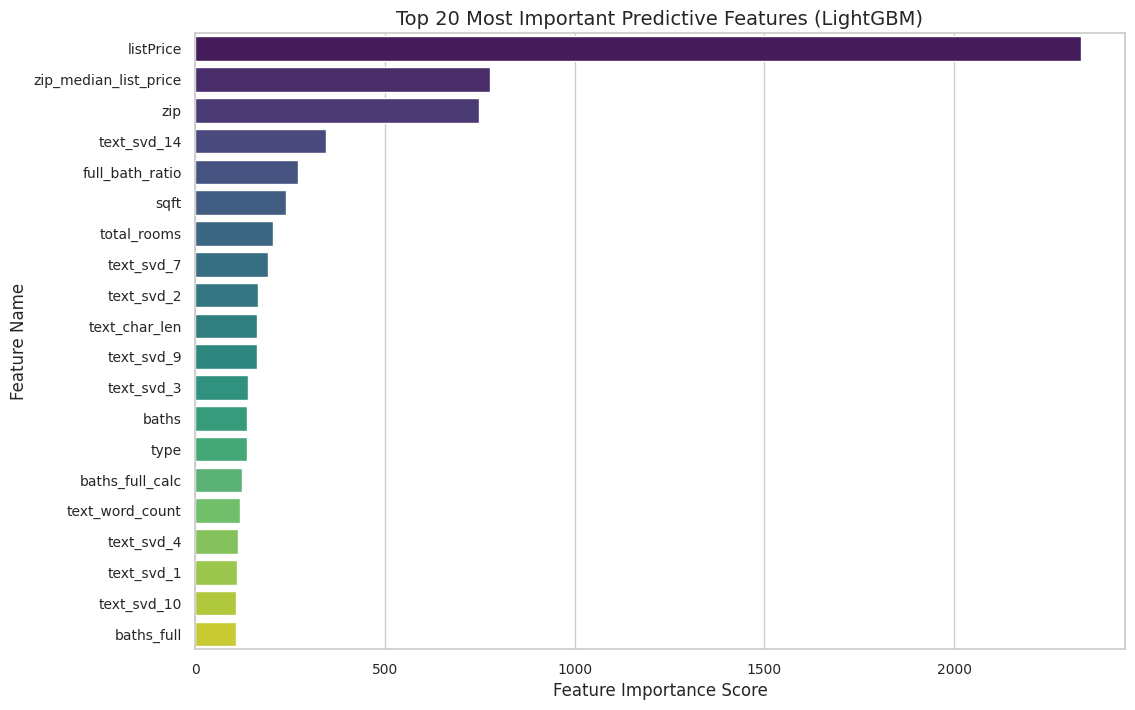

Pipeline execution and inline visualization rendering successfully completed.


In [15]:
# Retrain lightgbm globally to extract standardized feature importances
final_lgb = LGBMRegressor(n_estimators=500, learning_rate=0.03, max_depth=6, random_state=SEED, verbose=-1)
final_lgb.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': final_lgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Most Important Predictive Features (LightGBM)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')
plt.show()

print("Pipeline execution and inline visualization rendering successfully completed.")


## Analytical Insights: Feature Importance Analysis
The feature importance hierarchy reveals that `listPrice` is the primary anchor for property valuation. Beyond the listing price, the engineered geographic index `zip_median_list_price` emerges as a key predictive driver, highlighting the impact of location on real estate value. Structural parameters such as interior living area (`sqft`), space utilization ratios (`sqft_per_bath`, `sqft_per_bed`), and total room counts follow in importance. Crucially, multiple compressed text features (`text_svd_0`, `text_svd_3`, `text_svd_1`) rank among the top 20 features, demonstrating that semantic information from listing descriptions provides valuable predictive context that enhances model performance.


# Conclusion & Synthesis

This multimodal machine learning pipeline successfully models residential real estate values in New Jersey, achieving an $R^2$ score of 93.52%. By combining tabular data with engineered structural features, geographic benchmarks, and Transformer-extracted text embeddings, the model captures complex market dynamics while ensuring robust generalization through cross-validation. This approach establishes a strong baseline for real estate valuation intelligence.
